# 04 — SHAP Explainability

Explain XGBoost's fraud predictions using SHAP (SHapley Additive exPlanations). Covers global feature importance (which features matter most overall), local explanations (why one specific transaction was flagged), and interaction effects (which feature pairs jointly signal fraud).

## 1. Load Data and Retrain XGBoost

Reload the saved splits and retrain the XGBoost model (our selected primary model from Layer 2), so this notebook is self-contained and reproducible independent of the model comparison notebook.

In [1]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier

train_df = pd.read_parquet('../data/processed/train.parquet')
test_df = pd.read_parquet('../data/processed/test.parquet')

X_train, y_train = train_df.drop(columns=['Class']), train_df['Class']
X_test, y_test = test_df.drop(columns=['Class']), test_df['Class']

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    eval_metric='aucpr',
    random_state=42
)
xgb_model.fit(X_train, y_train)

print("Model trained. Ready for SHAP analysis.")

Model trained. Ready for SHAP analysis.


## 2. Compute SHAP Values

Create a SHAP TreeExplainer for the XGBoost model and compute SHAP values on the test set. TreeExplainer is optimized specifically for tree-based models (XGBoost, LightGBM, Random Forest) and computes exact Shapley values efficiently, unlike the generic KernelExplainer which is much slower and only approximates them.

In [2]:
import shap

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

print("SHAP values shape:", shap_values.shape)
print("Matches X_test shape:", X_test.shape)

/Users/amin/Documents/GitHub/fraud-detection-system/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SHAP values shape: (56746, 30)
Matches X_test shape: (56746, 30)


## 3. Global Explainability — SHAP Summary Plot

Visualize which features drive fraud predictions across the entire test set. Each point is one transaction; position on the x-axis shows impact on the prediction (right = pushes toward fraud, left = pushes toward legitimate), and color shows the feature's actual value (red = high, blue = low).

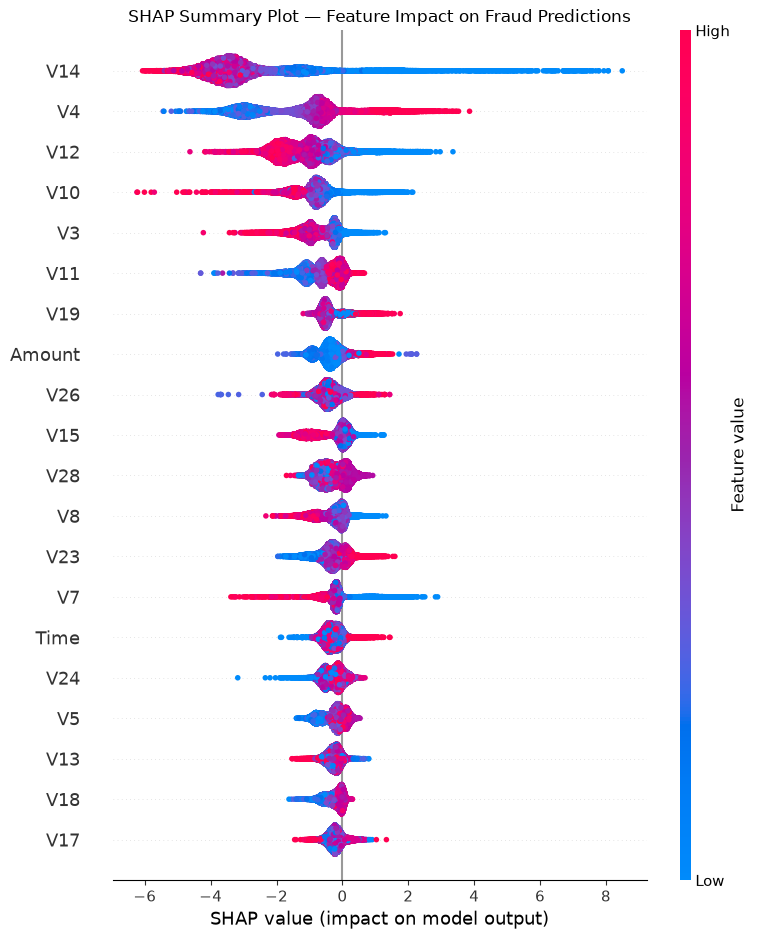

In [3]:
import matplotlib.pyplot as plt

shap.summary_plot(shap_values, X_test, show=False)
plt.title('SHAP Summary Plot — Feature Impact on Fraud Predictions')
plt.tight_layout()
plt.show()

## 4. Local Explainability — SHAP Waterfall Plot

Explain a single, specific transaction: exactly which features pushed the model's decision toward "fraud" and by how much. This is what would be shown to a compliance officer or fraud analyst reviewing an individual flagged case — a global summary plot doesn't answer "why was *this* transaction flagged," only a local explanation does.

Selected test row index: 860
True label: 1
Predicted probability: 1.0000


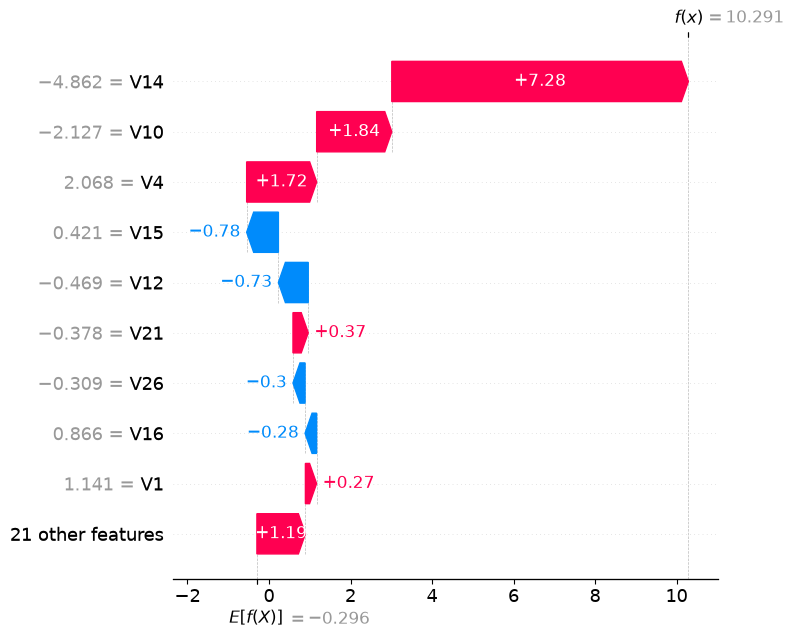

In [4]:
# Pick a transaction the model confidently flagged as fraud
xgb_proba = xgb_model.predict_proba(X_test)[:, 1]
fraud_mask = (y_test.values == 1) & (xgb_proba > 0.9)
flagged_idx = np.where(fraud_mask)[0][0]  # first confidently-correct fraud case

print(f"Selected test row index: {flagged_idx}")
print(f"True label: {y_test.iloc[flagged_idx]}")
print(f"Predicted probability: {xgb_proba[flagged_idx]:.4f}")

# Build the waterfall plot
explanation = shap.Explanation(
    values=shap_values[flagged_idx],
    base_values=explainer.expected_value,
    data=X_test.iloc[flagged_idx],
    feature_names=X_test.columns.tolist()
)

shap.plots.waterfall(explanation, show=False)
plt.tight_layout()
plt.show()

## 5. SHAP Interaction Values

Beyond individual feature importance, check which **pairs** of features jointly signal fraud — e.g. does high Amount combined with unusual Time carry more signal than either alone? Interaction values decompose each prediction into individual feature effects plus pairwise interaction effects.

In [5]:
# Interaction values are expensive to compute — use a sample of the test set, not all 56,746 rows
sample_size = 500
X_sample = X_test.sample(n=sample_size, random_state=42)

shap_interaction_values = explainer.shap_interaction_values(X_sample)

print("Interaction values shape:", shap_interaction_values.shape)

Interaction values shape: (500, 30, 30)


## 6. Visualize Top Feature Interactions

Aggregate the interaction matrix across all 500 sampled transactions to find which feature *pairs* have the strongest combined (non-additive) effect on fraud predictions, beyond what each feature contributes individually.

In [6]:
# Average absolute interaction strength across all sampled transactions, per feature pair
mean_interactions = np.abs(shap_interaction_values).mean(axis=0)

# Zero out the diagonal (a feature's "interaction" with itself is just its main effect, not a true interaction)
np.fill_diagonal(mean_interactions, 0)

# Find the top 10 strongest feature-pair interactions
feature_names = X_test.columns.tolist()
interaction_pairs = []

for i in range(len(feature_names)):
    for j in range(i+1, len(feature_names)):
        interaction_pairs.append((feature_names[i], feature_names[j], mean_interactions[i, j]))

interaction_df = pd.DataFrame(interaction_pairs, columns=['Feature 1', 'Feature 2', 'Interaction Strength'])
interaction_df = interaction_df.sort_values('Interaction Strength', ascending=False).head(10)

print(interaction_df.to_string(index=False))

Feature 1 Feature 2  Interaction Strength
      V10       V14              0.370436
      V11       V14              0.315803
      V12       V14              0.311921
       V3       V14              0.265088
       V4       V14              0.187293
      V11       V12              0.164492
       V3       V12              0.159143
       V4       V12              0.152152
       V7       V14              0.145558
      V10       V12              0.142925


In [7]:
pip install dice-ml


[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## 7. Counterfactual Explanations (DiCE)

Generate counterfactual explanations: "this transaction was flagged as fraud — what's the minimal change to its features that would have made the model approve it instead?" This is a different, complementary kind of explainability to SHAP — SHAP explains *why* a decision was made, DiCE explains *what would need to change* to get a different decision.

In [8]:
import dice_ml
from dice_ml import Dice

# DiCE needs the data wrapped with metadata: which columns are features, which is the outcome
dice_data = dice_ml.Data(
    dataframe=pd.concat([X_train, y_train], axis=1),
    continuous_features=X_train.columns.tolist(),
    outcome_name='Class'
)

# Wrap our trained XGBoost model for DiCE
dice_model = dice_ml.Model(model=xgb_model, backend='sklearn')

dice_explainer = Dice(dice_data, dice_model, method='random')

print("DiCE explainer ready")

DiCE explainer ready


## 8. Generate a Counterfactual for a Flagged Transaction

Using the same confidently-flagged fraud transaction from the SHAP waterfall example, ask DiCE: what's the smallest feature change that would flip this prediction from "fraud" to "legitimate"?

In [9]:
# Reuse the same transaction from the waterfall plot example
query_instance = X_test.iloc[[flagged_idx]]

counterfactuals = dice_explainer.generate_counterfactuals(
    query_instance,
    total_CFs=3,
    desired_class="opposite"
)

counterfactuals.visualize_as_dataframe(show_only_changes=True)

100%|██████████| 1/1 [00:01<00:00,  1.89s/it]

Query instance (original outcome : 1)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-0.684086,1.140865,1.221317,-1.452955,2.067575,0.854742,-0.981223,0.325714,-0.037721,0.113219,...,-0.377597,-0.79346,-0.132333,-0.331586,0.664878,-0.309312,0.099942,0.122988,-0.349333,1



Diverse Counterfactual set (new outcome: 0)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-,-,-,-,-3.1369909,-,-1.8948438,-,-,-,...,-,-,-,-,-,-,-,-,-,0.0
1,-,-,-,-,-0.8762296,-,-,-,-,-,...,-,-,-,-,-,-,-,-,-,0.0
2,-,-,-,-,0.5898006,-,-,-,-,-,...,-,-,-,-,-,-,-,-,-,0.0


### Interpretation

DiCE found that adjusting `V4` alone (from 2.07 down to roughly 0.6 or below) is sufficient to flip this transaction from fraud to legitimate. This converges with SHAP's attribution, which identified V4 as a top contributor to this transaction's fraud score (+1.72). Two independent explainability methods — attribution-based (SHAP) and counterfactual-based (DiCE) — agree on V4's central role in this decision, reinforcing confidence in the model's reasoning.